# 04 — Forecast Model (Revised)

## Objective
Build, evaluate, and compare demand forecasting models for Club Piscine franchise inventory planning.
Replaces Prophet-only approach with a **tiered modeling strategy** anchored by a global XGBoost model.

## Architecture

| Tier | Model | Scope | Why |
|------|-------|-------|-----|
| **1 – Primary** | XGBoost (global) | All groups pooled into one model | Uses lag features (strongest signal), handles non-linear interactions, learns cross-store patterns |
| **2 – Comparison** | Prophet + regressors | High-volume series only (≥12 wks, avg > $2k) | Baseline comparison, interpretable components |
| **3 – Simple** | Last-4-week average | Low-volume / intermittent series | Avoids overfitting noisy data; reported separately |

## Key Changes from v1
- **XGBoost global model** replaces Prophet as primary (uses all NB03 features including lags)
- **Tiered group classification** — low-volume/intermittent series separated from accuracy summary
- **Expanding-window cross-validation** — more robust evaluation than single holdout
- **Feature importance analysis** — validates which features actually drive predictions
- **Correlated feature pruning** — addresses the 34 correlated pairs from NB03
- **Division-season features** generated here if missing from NB03

## Inputs
- `data/processed/modeling_dataset.csv` — from NB03

## Outputs
| File | Description |
|------|-------------|
| `forecast_output.csv` | Forward forecasts per store × division |
| `model_accuracy.csv` | wMAPE, RMSE, MAE per group per model |
| `baseline_comparison.csv` | XGBoost vs Prophet vs Naive vs MA |
| `forecast_output_by_store.csv` | Store-level aggregated forecasts |
| `inventory_gap_analysis.csv` | Forecast demand vs current inventory |
| `feature_importance.csv` | XGBoost feature importances |

## Evaluation
- **Primary metric:** wMAPE — `sum(|actual − forecast|) / sum(actual)`
- **Target:** Median wMAPE < 30% for Tier 1 high-volume divisions

## Data Limitation
Only 14 weeks of history (June–Sept 2025). Prototype only.
---

---
## Cell 1 — Imports and Configuration
---

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import logging
from pathlib import Path
from scipy import stats

from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error
from sklearn.preprocessing import LabelEncoder

warnings.filterwarnings('ignore')
logging.getLogger('prophet').setLevel(logging.ERROR)
logging.getLogger('cmdstanpy').setLevel(logging.ERROR)

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.size'] = 10
plt.rcParams['figure.figsize'] = (14, 6)
sns.set_palette('husl')

PROJECT_ROOT   = Path('..')
DATA_RAW       = PROJECT_ROOT / 'data' / 'raw'
DATA_PROCESSED = PROJECT_ROOT / 'data' / 'processed'
FIGURES        = PROJECT_ROOT / 'reports' / 'figures'
FIGURES.mkdir(parents=True, exist_ok=True)

# ─────────────────────────────────────────────
# MODEL CONFIGURATION
# ─────────────────────────────────────────────
FORECAST_HORIZON   = 4       # Weeks to predict ahead (production)
EVAL_HORIZON       = 1       # 1 week holdout — tight but allows summer-only eval with 9 weeks
MIN_HISTORY        = 6       # Lowered for 14-week dataset
CONFIDENCE_LEVEL   = 0.95
N_CV_FOLDS         = 3       # Expanding-window CV folds

# ── Tiering thresholds ──
LOW_VOLUME_THRESHOLD = 200   # Avg weekly sales ($) below this → Tier 3
HIGH_CV_THRESHOLD    = 1.5   # CV above this → Tier 3
PROPHET_MIN_WEEKS    = 12
PROPHET_MIN_SALES    = 2000

# ── Store → City mapping for 27 active stores (CP77/CP100 regrouped in NB01) ──
STORE_TO_CITY = {
    'CP02':'Blainville',       'CP04':'Drummondville',    'CP05':'Sherbrooke',
    'CP06':'Granby',           'CP07':'Laval',            'CP08':'Longueuil',
    'CP10':'Saint-Jérôme',     'CP12':'St-Georges-de-Beauce', 'CP13':'Victoriaville',
    'CP15':'Repentigny',       'CP16':'Chicoutimi',       'CP17':'Trois-Rivières',
    'CP18':"Val-d'Or",         'CP202':'Nepean',          'CP28':'Pointe-aux-Trembles',
    'CP32':'St-Hyacinthe',     'CP33':'Sorel-Tracy',
    'CP35':'Saint-Jean-sur-Richelieu', 'CP36':'Saint-Eustache',
    'CP37':'Gatineau',         'CP39':'Joliette',         'CP40':'Thetford Mines',
    'CP44':'St-Constant',      'CP45':'Cowansville',
    'CP46':'Sainte-Agathe-des-Monts',  'CP47':'Riviere-du-Loup',
    'CP48':'Beloeil',
}

# ── Feature groups (synced with NB03 output) ──
GROUP_COLS = ['store_code', 'city', 'division_code']

LAG_FEATURES = [
    # Unit lags
    'units_lag_1w', 'units_lag_2w', 'units_lag_4w', 'units_lag_52w',
    # Rolling windows (4w, 8w, 12w)
    'units_roll4_mean', 'units_roll4_std',
    'units_roll8_mean', 'units_roll8_std',
    'units_roll12_mean', 'units_roll12_std',
    # Demand volatility
    'units_volatility',
    # Revenue lags (for product mix signal)
    'revenue_lag_1w', 'revenue_lag_4w', 'revenue_roll4_mean',
    'avg_price_per_unit', 'price_lag_1w',
]

SEASONALITY_FEATURES = [
    'sin_week_1', 'cos_week_1', 'sin_week_2', 'cos_week_2',
    'sin_month_1', 'cos_month_1'
]

CALENDAR_FEATURES = [
    'year_idx', 'quarter', 'week_of_yr', 'month',
    'has_holiday', 'n_holidays',
    'is_summer_peak', 'is_spring_opening', 'is_fall_closing'
]

WEATHER_FEATURES = [
    # Raw weather
    'avg_temp', 'total_precip', 'sunshine_hours',
    'rain_days', 'snow_days', 'bad_weather_days',
    # Threshold flags
    'temp_above_20', 'temp_above_25', 'temp_below_0',
    'cooling_degree_days', 'heating_degree_days',
    # Deviation z-scores
    'avg_temp_dev_z', 'total_precip_dev_z',
    'sunshine_hours_dev_z', 'rain_days_dev_z',
    'snow_days_dev_z', 'bad_weather_days_dev_z',
    # Temperature lags and shock (from NB03)
    'avg_temp_lag_1w', 'avg_temp_lag_2w',
    'temp_shock', 'temp_warming',
    # Weather × Season interactions (from NB03)
    'precip_x_summer', 'bad_wx_x_summer', 'sunshine_x_summer',
    'temp_above_25_x_sum', 'precip_x_spring', 'temp_warming_x_spr',
]

PROPHET_REGRESSORS = [
    'avg_temp', 'bad_weather_days', 'snow_days', 'has_holiday',
    'is_summer_peak', 'cooling_degree_days'
]

print('✅ Configuration:')
print(f'   Forecast horizon     : {FORECAST_HORIZON} weeks')
print(f'   Eval holdout per fold: {EVAL_HORIZON} weeks × {N_CV_FOLDS} folds')
print(f'   Tiering: low-vol < ${LOW_VOLUME_THRESHOLD}/wk, high-CV > {HIGH_CV_THRESHOLD}')
print(f'   Lag features         : {len(LAG_FEATURES)} (incl. 52w YoY, revenue lags, volatility)')
print(f'   Weather features     : {len(WEATHER_FEATURES)} (incl. temp shock, interactions)')
print(f'   Prophet regressors   : {PROPHET_REGRESSORS}')
# Division labels for readability in outputs
DIV_LABELS = {
    'FI':'Fitness',        'BQ':'BBQ',
    'GA':'Gazebo et Abri', 'ME':'Meuble',
    'PA':'Parasol',        'CH':'Chauffe-eau & Thermopompe',
    'HT':'Piscine hors-terre', 'TO':'Toile de piscine',
    'PC':'Produit chimique', 'LO':'Loisir',
    'SP':'Spa',
}

✅ Configuration:
   Forecast horizon     : 4 weeks
   Eval holdout per fold: 1 weeks × 3 folds
   Tiering: low-vol < $200/wk, high-CV > 1.5
   Lag features         : 16 (incl. 52w YoY, revenue lags, volatility)
   Weather features     : 27 (incl. temp shock, interactions)
   Prophet regressors   : ['avg_temp', 'bad_weather_days', 'snow_days', 'has_holiday', 'is_summer_peak', 'cooling_degree_days']


---
## Cell 2 — Load Data, Ensure Schema, Enrich Features

Loads `modeling_dataset.csv` from NB03.
Rebuilds `city` from store mapping if missing.
Creates division-season interaction features if not in NB03 output.
Fills implicit zero-sale weeks and recomputes lags.
---

In [16]:
df = pd.read_csv(DATA_PROCESSED / 'modeling_dataset.csv')
df['week_ending'] = pd.to_datetime(df['week_ending'])

# ── Column diagnostics ──
print(f'Columns from modeling_dataset.csv ({len(df.columns)}):')
print(df.columns.tolist())

# ── Normalize column names ──
COLUMN_MAP = {
    'No. magasin': 'store_code', 'No magasin': 'store_code',
    'Division Code': 'division_code',
    'Ville magasins': 'city', 'Ville': 'city',
}
df = df.rename(columns={k: v for k, v in COLUMN_MAP.items() if k in df.columns})

# Clean up duplicate store_code columns that can appear from nb02/nb03 merges
if 'store_code_x' in df.columns and 'store_code_y' in df.columns:
    df['store_code'] = df['store_code_x'].fillna(df['store_code_y'])
    df = df.drop(columns=['store_code_x', 'store_code_y'])
elif 'store_code_x' in df.columns:
    df = df.rename(columns={'store_code_x': 'store_code'}).drop(columns=['store_code_y'], errors='ignore')

STORE_TO_CITY = {
    'CP02': 'Blainville',          'CP04': 'Drummondville',
    'CP06': 'Granby',              'CP07': 'Laval',
    'CP08': 'Longueuil',           'CP10': 'Saint-Jérôme',
    'CP13': 'Victoriaville',       'CP15': 'Repentigny',
    'CP16': 'Chicoutimi',          'CP17': 'Trois-Rivières',
    'CP202': 'Nepean',             'CP28': 'Pointe-aux-Trembles',
    'CP32': 'St-Hyacinthe',        'CP33': 'Sorel-Tracy',
    'CP35': 'Saint-Jean-sur-Richelieu', 'CP36': 'Saint-Eustache',
    'CP37': 'Gatineau',            'CP39': 'Joliette',
    'CP44': 'St-Constant',         'CP45': 'Cowansville',
    'CP46': 'Sainte-Agathe-des-Monts', 'CP48': 'Beloeil',
}
if 'city' not in df.columns:
    print('  → city missing — mapping from store_code')
    df['city'] = df['store_code'].map(STORE_TO_CITY)
else:
    df['city'] = df['city'].fillna(df['store_code'].map(STORE_TO_CITY))

for col in ['units', 'n_transactions']:
    if col not in df.columns:
        df[col] = 0

for req in ['store_code', 'division_code', 'units', 'week_ending', 'city']:
    assert req in df.columns, f'Missing: {req}. Have: {df.columns.tolist()}'

# Apply division whitelist — keep only the 11 final divisions
if 'FINAL_DIVS' in dir() and len(FINAL_DIVS) > 0:
    before_divs = df['division_code'].nunique()
    df = df[df['division_code'].isin(FINAL_DIVS)].copy()
    print(f'Division whitelist: {before_divs} → {df["division_code"].nunique()} divisions')

df = df.sort_values(['store_code', 'division_code', 'week_ending']).reset_index(drop=True)

print(f'\nDataset: {df.shape[0]:,} rows × {df.shape[1]} cols')
print(f'Date range: {df["week_ending"].min().date()} → {df["week_ending"].max().date()}')
print(f'Stores: {sorted(df["store_code"].unique())}')
print(f'Divisions: {sorted(df["division_code"].unique())}')
print(f'Groups: {df.groupby(GROUP_COLS).ngroups}')

# ── Division-season features (division flags + division × season/temp) ──
# These are NB04-specific (not in NB03) because they depend on division groupings
POOL_DIVS    = ['PC', 'PI', 'CH', 'AP']
OUTDOOR_DIVS = ['GA', 'BQ', 'ME', 'SP']
FITNESS_DIVS = ['FI', 'HT']

if 'is_pool_div' not in df.columns:
    print('\n  → Creating division-season features')
    df['is_pool_div']    = df['division_code'].isin(POOL_DIVS).astype(int)
    df['is_outdoor_div'] = df['division_code'].isin(OUTDOOR_DIVS).astype(int)
    df['is_fitness_div'] = df['division_code'].isin(FITNESS_DIVS).astype(int)

if 'pool_x_summer' not in df.columns:
    summer = df['is_summer_peak'] if 'is_summer_peak' in df.columns else 0
    df['pool_x_summer']    = df['is_pool_div'] * summer
    df['outdoor_x_summer'] = df['is_outdoor_div'] * summer
    if 'avg_temp' in df.columns:
        df['pool_x_temp']    = df['is_pool_div'] * df['avg_temp']
        df['outdoor_x_temp'] = df['is_outdoor_div'] * df['avg_temp']

# temp_x_summer is NB04-only; precip_x_summer and bad_wx_x_summer now come from NB03
if 'temp_x_summer' not in df.columns and 'avg_temp' in df.columns:
    summer = df['is_summer_peak'] if 'is_summer_peak' in df.columns else 0
    df['temp_x_summer'] = df['avg_temp'] * summer
    # Only create these if NB03 didn't already (backward compatibility)
    if 'precip_x_summer' not in df.columns and 'total_precip' in df.columns:
        df['precip_x_summer'] = df['total_precip'] * summer
    if 'bad_wx_x_summer' not in df.columns and 'bad_weather_days' in df.columns:
        df['bad_wx_x_summer'] = df['bad_weather_days'] * summer

# ══════════════════════════════════════════════════════════════════
# PANEL FILL — for lag computation only, NOT for training/evaluation
# ══════════════════════════════════════════════════════════════════
# Tag original rows BEFORE panel fill
df['is_original'] = True

all_weeks = sorted(df['week_ending'].unique())
all_groups = df[GROUP_COLS].drop_duplicates()
full_index = all_groups.merge(pd.DataFrame({'week_ending': all_weeks}), how='cross')
n_before = len(df)
df = full_index.merge(df, on=GROUP_COLS + ['week_ending'], how='left')
df['is_original'] = df['is_original'].fillna(False)
# units/revenue filled below
df['units'] = df['units'].fillna(0)
df['revenue'] = df['revenue'].fillna(0) if 'revenue' in df.columns else 0
df['n_transactions'] = df['n_transactions'].fillna(0)
n_synthetic = (~df['is_original']).sum()
print(f'\nPanel fill: {n_before:,} original + {n_synthetic:,} synthetic zeros = {len(df):,} total')

# Recompute ALL lag features on full panel (so lags don't skip gaps)
def recompute_lags(group):
    group = group.sort_values('week_ending').copy()

    # ── Unit lags ──
    for lag in [1, 2, 4]:
        group[f'units_lag_{lag}w'] = group['units'].shift(lag)
    group['units_lag_52w'] = group['units'].shift(52)

    # ── Rolling windows (4w, 8w, 12w) ──
    shifted = group['units'].shift(1)
    for win in [4, 8, 12]:
        min_p = max(2, win // 2)
        group[f'units_roll{win}_mean'] = shifted.rolling(win, min_periods=min_p).mean()
        group[f'units_roll{win}_std']  = shifted.rolling(win, min_periods=min_p).std().fillna(0)

    # ── Demand volatility ──
    group['units_volatility'] = (
        group['units_roll4_std'] /
        group['units_roll4_mean'].replace(0, np.nan)
    )

    # ── Revenue lags ──
    if 'revenue' in group.columns:
        for lag in [1, 4]:
            group[f'revenue_lag_{lag}w'] = group['revenue'].shift(lag)
        group['revenue_roll4_mean'] = group['revenue'].shift(1).rolling(4, min_periods=2).mean()
        group['avg_price_per_unit'] = (
            group['revenue'] / group['units'].replace(0, np.nan)
        )
        group['price_lag_1w'] = group['avg_price_per_unit'].shift(1)

    # ── Temperature lags (recompute on filled panel) ──
    if 'avg_temp' in group.columns:
        group['avg_temp_lag_1w'] = group['avg_temp'].shift(1)
        group['avg_temp_lag_2w'] = group['avg_temp'].shift(2)
        group['temp_shock']      = (group['avg_temp'] - group['avg_temp_lag_1w']).abs()
        group['temp_warming']    = (group['avg_temp'] - group['avg_temp_lag_1w']).clip(lower=0)

    return group

_parts = []
for _keys, _grp in df.groupby(GROUP_COLS):
    _parts.append(recompute_lags(_grp))
df = pd.concat(_parts, ignore_index=True)

# Fill weather/calendar NaNs for synthetic rows
fill_candidates = [c for c in df.columns if c in
    WEATHER_FEATURES + CALENDAR_FEATURES + SEASONALITY_FEATURES +
    ['month', 'year', 'week_of_yr', 'is_winter_off', 'province',
     'is_pool_div', 'is_outdoor_div', 'is_fitness_div',
     'pool_x_summer', 'outdoor_x_summer', 'pool_x_temp', 'outdoor_x_temp',
     'temp_x_summer']]

for col in fill_candidates:
    if col not in df.columns or not df[col].isna().any():
        continue
    # First pass: fill from same store+week (weather/calendar same across divisions)
    df[col] = df.groupby(['store_code', 'week_ending'])[col].transform('first')
    # Second pass: fill any remaining NaNs
    if df[col].isna().any():
        if pd.api.types.is_numeric_dtype(df[col]):
            df[col] = df[col].fillna(df[col].median())
        else:
            # String columns (e.g. province): fill with most common value
            mode_val = df[col].mode()
            df[col] = df[col].fillna(mode_val[0] if len(mode_val) else 'QC')

# Replace inf values in price features (from 0-unit division)
for col in ['avg_price_per_unit', 'price_lag_1w']:
    if col in df.columns:
        df[col] = df[col].replace([np.inf, -np.inf], np.nan).fillna(0)

# ══════════════════════════════════════════════════════════════════
# NOW DROP SYNTHETIC ROWS — they served their purpose for lag computation
# ══════════════════════════════════════════════════════════════════
df = df[df['is_original']].drop(columns=['is_original']).reset_index(drop=True)
print(f'After dropping synthetic rows: {len(df):,} rows (original data only)')
print(f'Final: {df.shape[0]:,} rows × {df.shape[1]} cols')

Columns from modeling_dataset.csv (81):
['week_ending', 'store_code_x', 'city', 'division_code', 'units', 'revenue', 'n_transactions', 'revenue_clean', 'is_return', 'is_active_product', 'weeks_with_sales', 'store_code_y', 'province', 'avg_temp', 'max_temp', 'total_precip', 'sunshine_hours', 'rain_days', 'snow_days', 'bad_weather_days', 'store_code', 'n_holidays', 'has_holiday', 'month', 'week_of_yr', 'year', 'sin_week_1', 'cos_week_1', 'sin_week_2', 'cos_week_2', 'sin_month_1', 'cos_month_1', 'year_idx', 'quarter', 'is_summer_peak', 'is_spring_opening', 'is_fall_closing', 'is_winter_off', 'avg_temp_dev', 'avg_temp_dev_z', 'total_precip_dev', 'total_precip_dev_z', 'sunshine_hours_dev', 'sunshine_hours_dev_z', 'rain_days_dev', 'rain_days_dev_z', 'snow_days_dev', 'snow_days_dev_z', 'bad_weather_days_dev', 'bad_weather_days_dev_z', 'temp_above_20', 'temp_above_25', 'temp_below_0', 'cooling_degree_days', 'heating_degree_days', 'avg_temp_lag_1w', 'avg_temp_lag_2w', 'temp_shock', 'temp_warmin

---
## Cell 3 — Group Classification (Tier Assignment)

- **Tier 1 (XGBoost):** Sufficient history and stable enough for ML
- **Tier 2 (Prophet-eligible):** High-volume subset of Tier 1
- **Tier 3 (Simple baseline):** Low-volume or highly intermittent
- **Skip:** Insufficient history
---

In [17]:
group_stats = (
    df.groupby(GROUP_COLS)
    .agg(
        n_weeks=('week_ending', 'nunique'),
        n_nonzero=('units', lambda x: (x > 0).sum()),
        avg_sales=('units', 'mean'),
        median_sales=('units', 'median'),
        std_sales=('units', 'std'),
        total_sales=('units', 'sum'),
        max_sales=('units', 'max'),
        min_sales=('units', 'min')
    )
    .reset_index()
)
group_stats['cv'] = group_stats['std_sales'] / group_stats['avg_sales'].clip(lower=1)
group_stats['zero_rate'] = 1 - (group_stats['n_nonzero'] / group_stats['n_weeks'])

# ── Assign tiers (tighter criteria) ──
group_stats['tier'] = 'skip'

mask_enough = (group_stats['n_weeks'] >= MIN_HISTORY + EVAL_HORIZON)

# Must have meaningful sales: avg > $500/wk AND >70% weeks with sales
mask_stable = (
    (group_stats['avg_sales'] >= 500) &
    (group_stats['zero_rate'] < 0.30) &
    (group_stats['cv'] <= 2.0)
)
group_stats.loc[mask_enough & mask_stable, 'tier'] = 'xgboost'

# Tier 3: has enough weeks but too sparse or low-volume
mask_tier3 = mask_enough & ~mask_stable
group_stats.loc[mask_tier3, 'tier'] = 'simple'

# Prophet eligibility: high-volume stable series
mask_prophet = (
    (group_stats['tier'] == 'xgboost') &
    (group_stats['n_weeks'] >= PROPHET_MIN_WEEKS) &
    (group_stats['avg_sales'] >= PROPHET_MIN_SALES) &
    (group_stats['cv'] <= 1.0)
)
group_stats['prophet_eligible'] = mask_prophet

print('=' * 70)
print('GROUP CLASSIFICATION')
print('=' * 70)
for tier in ['xgboost', 'simple', 'skip']:
    t = group_stats[group_stats['tier'] == tier]
    avg_s = t['avg_sales'].mean() if len(t) > 0 else 0
    avg_w = t['n_weeks'].mean() if len(t) > 0 else 0
    print(f'  {tier.upper():<12}: {len(t):>3} groups  '
          f'(avg sales: ${avg_s:>10,.0f}, avg weeks: {avg_w:>4.0f})')

n_prophet = group_stats['prophet_eligible'].sum()
print(f'  PROPHET     : {n_prophet:>3} groups (comparison model)')
print()

t1 = group_stats[group_stats['tier'] == 'xgboost'].sort_values('total_sales', ascending=False)
print('Tier 1 (XGBoost) groups:')
print(t1[['store_code', 'division_code', 'n_weeks', 'avg_sales', 'cv', 'zero_rate', 'prophet_eligible']].head(25).to_string(index=False))

t3 = group_stats[group_stats['tier'] == 'simple']
if len(t3) > 0:
    print(f'\nTier 3 (Simple): {len(t3)} groups')
    print(t3[['store_code', 'division_code', 'avg_sales', 'cv', 'zero_rate']].head(15).to_string(index=False))

print(f'\nSkipped: {(group_stats["tier"]=="skip").sum()} groups')

# Attach to main df
df = df.merge(group_stats[GROUP_COLS + ['tier', 'prophet_eligible', 'avg_sales', 'cv']],
              on=GROUP_COLS, how='left', suffixes=('', '_grp'))


GROUP CLASSIFICATION
  XGBOOST     :  17 groups  (avg sales: $       723, avg weeks:  121)
  SIMPLE      : 276 groups  (avg sales: $        29, avg weeks:   81)
  SKIP        :   5 groups  (avg sales: $         4, avg weeks:    2)
  PROPHET     :   0 groups (comparison model)

Tier 1 (XGBoost) groups:
store_code division_code  n_weeks   avg_sales       cv  zero_rate  prophet_eligible
      CP37            PC      125 1046.600000 1.103507        0.0             False
      CP07            PC      125 1041.176000 1.195700        0.0             False
      CP35            PC      122  909.122951 1.190296        0.0             False
      CP06            PC      125  811.616000 1.173136        0.0             False
      CP36            PC      125  750.520000 1.419959        0.0             False
      CP10            PC      123  697.495935 1.101918        0.0             False
      CP05            PC       77 1069.662338 1.417158        0.0             False
      CP15            PC 

---
## Cell 4 — Correlated Feature Pruning

NB03 flagged 34 highly correlated feature pairs. Drop the weaker of each pair.
---

In [18]:
DIVISION_FEATURES = [c for c in df.columns if c.startswith((
    'is_pool', 'is_outdoor', 'is_fitness',
    'pool_x', 'outdoor_x',
    'temp_x', 'precip_x', 'bad_wx',
    'sunshine_x', 'temp_above_25_x', 'temp_warming_x'
))]
ALL_FEATURE_CANDIDATES = (
    LAG_FEATURES + SEASONALITY_FEATURES + CALENDAR_FEATURES +
    WEATHER_FEATURES + DIVISION_FEATURES
)
# Deduplicate (interactions may appear in both WEATHER_FEATURES and DIVISION_FEATURES)
ALL_FEATURE_CANDIDATES = list(dict.fromkeys(ALL_FEATURE_CANDIDATES))
available_features = [f for f in ALL_FEATURE_CANDIDATES if f in df.columns]
print(f'Feature candidates: {len(available_features)} (from {len(ALL_FEATURE_CANDIDATES)} total)')

# ── Prune highly correlated pairs (|r| > 0.92) ──
df_numeric = df[available_features].dropna()
to_drop = set()

if len(df_numeric) > 100:
    corr_matrix = df_numeric.corr().abs()
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    target_corrs = df[['units'] + available_features].corr()['units'].abs()

    for col in upper.columns:
        high_corr_partners = upper.index[upper[col] > 0.92].tolist()
        for partner in high_corr_partners:
            if col in to_drop or partner in to_drop:
                continue
            if target_corrs.get(col, 0) >= target_corrs.get(partner, 0):
                to_drop.add(partner)
            else:
                to_drop.add(col)

    to_drop = list(to_drop)
    print(f'\nDropping {len(to_drop)} highly correlated features: {sorted(to_drop)}')
    available_features = [f for f in available_features if f not in to_drop]

FINAL_FEATURES = available_features.copy()
print(f'\n✅ Final feature set: {len(FINAL_FEATURES)} features')
for i, f in enumerate(FINAL_FEATURES):
    print(f'  {i+1:>2}. {f}')

Feature candidates: 66 (from 66 total)

Dropping 18 highly correlated features: ['avg_temp', 'avg_temp_lag_1w', 'cos_month_1', 'month', 'n_holidays', 'outdoor_x_summer', 'precip_x_spring', 'quarter', 'sin_month_1', 'sunshine_x_summer', 'temp_above_20', 'temp_x_summer', 'units_lag_2w', 'units_lag_4w', 'units_roll12_mean', 'units_roll4_mean', 'units_roll8_mean', 'units_roll8_std']

✅ Final feature set: 48 features
   1. units_lag_1w
   2. units_lag_52w
   3. units_roll4_std
   4. units_roll12_std
   5. units_volatility
   6. revenue_lag_1w
   7. revenue_lag_4w
   8. revenue_roll4_mean
   9. avg_price_per_unit
  10. price_lag_1w
  11. sin_week_1
  12. cos_week_1
  13. sin_week_2
  14. cos_week_2
  15. year_idx
  16. week_of_yr
  17. has_holiday
  18. is_summer_peak
  19. is_spring_opening
  20. is_fall_closing
  21. total_precip
  22. sunshine_hours
  23. rain_days
  24. snow_days
  25. bad_weather_days
  26. temp_above_25
  27. temp_below_0
  28. cooling_degree_days
  29. heating_degree_

---
## Cell 5 — XGBoost Global Model with Expanding-Window CV

Single global model trained across ALL Tier 1 store-division groups.
Expanding-window CV: train on weeks 1→T, test on T+1→T+2, three folds.
---

In [19]:
df_t1 = df[df['tier'] == 'xgboost'].copy()

le_store = LabelEncoder()
le_div   = LabelEncoder()
df_t1['store_enc'] = le_store.fit_transform(df_t1['store_code'])
df_t1['div_enc']   = le_div.fit_transform(df_t1['division_code'])

XGBOOST_FEATURES = FINAL_FEATURES + ['store_enc', 'div_enc']
XGBOOST_FEATURES = [f for f in XGBOOST_FEATURES if f in df_t1.columns]

lag_cols_present = [c for c in LAG_FEATURES if c in df_t1.columns]
df_model = df_t1.dropna(subset=lag_cols_present).copy()

print(f'Tier 1 modeling data: {len(df_model):,} rows, {len(XGBOOST_FEATURES)} features')

sorted_weeks = sorted(df_model['week_ending'].unique())
n_weeks = len(sorted_weeks)
summer_weeks = [w for w in sorted_weeks if w.month <= 8]
sept_weeks   = [w for w in sorted_weeks if w.month >= 9]

print(f'\n{"="*70}')
print('EVALUATION STRATEGY')
print(f'{"="*70}')
print(f'Total weeks     : {n_weeks}')
print(f'Summer weeks    : {len(summer_weeks)} (Jun-Aug)')
print(f'September weeks : {len(sept_weeks)} (cliff, excluded from eval)')

# FORCE summer-only eval — this is the whole point
# With EVAL_HORIZON=1 and MIN_HISTORY=6, we need 7 summer weeks minimum
if len(summer_weeks) >= MIN_HISTORY + EVAL_HORIZON:
    eval_weeks = summer_weeks
    print(f'\n=> Using SUMMER-ONLY evaluation ({len(eval_weeks)} weeks)')
else:
    # True fallback: use all but explicitly warn
    eval_weeks = sorted_weeks
    print(f'\n=> WARNING: Not enough summer weeks, using all {len(eval_weeks)} weeks (includes Sep cliff)')

print(f'  Eval range: {eval_weeks[0].date()} -> {eval_weeks[-1].date()}')
print(f'  MIN_HISTORY={MIN_HISTORY}, EVAL_HORIZON={EVAL_HORIZON}, needed={MIN_HISTORY+EVAL_HORIZON}')

cv_results_all = []
cv_fold_metrics = []

for fold in range(N_CV_FOLDS):
    test_end_idx   = len(eval_weeks) - fold * EVAL_HORIZON
    test_start_idx = test_end_idx - EVAL_HORIZON
    if test_start_idx < MIN_HISTORY:
        print(f'  Fold {fold+1}: skipped (train would be {test_start_idx} weeks < {MIN_HISTORY})')
        continue

    train_wks = eval_weeks[:test_start_idx]
    test_wks  = eval_weeks[test_start_idx:test_end_idx]

    train_data = df_model[df_model['week_ending'].isin(train_wks)]
    test_data  = df_model[df_model['week_ending'].isin(test_wks)]

    if len(train_data) < 20 or len(test_data) < 3 or test_data['units'].sum() < 50:
        print(f'  Fold {fold+1}: skipped (train={len(train_data)} rows, test={len(test_data)} rows)')
        continue

    X_train = train_data[XGBOOST_FEATURES].fillna(0)
    y_train = train_data['units']
    X_test  = test_data[XGBOOST_FEATURES].fillna(0)
    y_test  = test_data['units']

    xgb_model = XGBRegressor(
        n_estimators=200, max_depth=4, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.7, min_child_weight=10,
        reg_alpha=1.0, reg_lambda=3.0, gamma=0.2,
        random_state=42, verbosity=0
    )
    xgb_model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)

    preds = xgb_model.predict(X_test).clip(min=0)
    test_copy = test_data[GROUP_COLS + ['week_ending', 'units']].copy()
    test_copy['pred'] = preds
    test_copy['fold'] = fold + 1
    cv_results_all.append(test_copy)

    fold_wmape = np.abs(y_test.values - preds).sum() / max(y_test.sum(), 1)
    fold_rmse  = np.sqrt(np.mean((y_test.values - preds)**2))
    cv_fold_metrics.append({
        'fold': fold+1, 'train_weeks': len(train_wks), 'test_weeks': len(test_wks),
        'train_rows': len(train_data), 'test_rows': len(test_data),
        'wMAPE': round(fold_wmape, 4), 'RMSE': round(fold_rmse, 2)
    })
    print(f'  Fold {fold+1}: train={len(train_wks)}wk ({len(train_data)} rows) -> '
          f'test={len(test_wks)}wk ({len(test_data)} rows)  '
          f'wMAPE={fold_wmape:.1%}  RMSE=${fold_rmse:,.0f}')

if len(cv_results_all) > 0:
    cv_results = pd.concat(cv_results_all, ignore_index=True)
    cv_metrics = pd.DataFrame(cv_fold_metrics)
    print(f'\n  Average across {len(cv_metrics)} folds: wMAPE={cv_metrics["wMAPE"].mean():.1%}  '
          f'RMSE=${cv_metrics["RMSE"].mean():,.0f}')
else:
    cv_results = pd.DataFrame(columns=GROUP_COLS + ['week_ending', 'units', 'pred', 'fold'])
    cv_metrics = pd.DataFrame(columns=['fold', 'wMAPE', 'RMSE'])
    print('\n  Warning: No CV folds completed')


Tier 1 modeling data: 1,229 rows, 50 features

EVALUATION STRATEGY
Total weeks     : 73
Summer weeks    : 47 (Jun-Aug)
September weeks : 26 (cliff, excluded from eval)

=> Using SUMMER-ONLY evaluation (47 weeks)
  Eval range: 2025-01-05 -> 2026-03-22
  MIN_HISTORY=6, EVAL_HORIZON=1, needed=7
  Fold 1: train=46wk (773 rows) -> test=1wk (17 rows)  wMAPE=96.6%  RMSE=$57
  Fold 2: train=45wk (756 rows) -> test=1wk (17 rows)  wMAPE=32.4%  RMSE=$37
  Fold 3: train=44wk (739 rows) -> test=1wk (17 rows)  wMAPE=41.1%  RMSE=$65

  Average across 3 folds: wMAPE=56.7%  RMSE=$53


---
## Cell 6 — Per-Group Accuracy from XGBoost CV
---

In [20]:
xgb_group_metrics = []

for (store, city, div), grp in cv_results.groupby(GROUP_COLS):
    actuals = grp['units'].values
    preds   = grp['pred'].values

    # Skip groups where test actuals sum to ~zero
    if len(actuals) < 2 or actuals.sum() < 10:
        continue

    abs_err = np.abs(actuals - preds)
    wmape   = abs_err.sum() / actuals.sum()   # clean denominator, no 1e-6 hack
    rmse    = np.sqrt(np.mean((actuals - preds)**2))
    mae     = np.mean(abs_err)
    bias    = np.mean(preds - actuals)
    xgb_group_metrics.append({
        'store_code': store, 'city': city, 'division_code': div,
        'wMAPE': round(wmape, 4), 'RMSE': round(rmse, 2),
        'MAE': round(mae, 2), 'Bias': round(bias, 2),
        'Avg_Sales': round(actuals.mean(), 2), 'model': 'XGBoost_Global'
    })

xgb_accuracy = pd.DataFrame(xgb_group_metrics)

print('=' * 80)
print('XGBOOST GLOBAL MODEL — PER-GROUP ACCURACY')
print('=' * 80)
print(f'Groups evaluated: {len(xgb_accuracy)}')
if len(xgb_accuracy) > 0:
    print(f'Overall wMAPE   : {xgb_accuracy["wMAPE"].mean():.1%}  (median: {xgb_accuracy["wMAPE"].median():.1%})')
    print(f'Overall RMSE    : ${xgb_accuracy["RMSE"].mean():,.0f}')
    print(f'Overall Bias    : ${xgb_accuracy["Bias"].mean():,.0f}')
    print()

    n_good = (xgb_accuracy['wMAPE'] < 0.30).sum()
    n_ok   = ((xgb_accuracy['wMAPE'] >= 0.30) & (xgb_accuracy['wMAPE'] < 0.60)).sum()
    n_poor = (xgb_accuracy['wMAPE'] >= 0.60).sum()
    print(f'Quality tiers:  ✓ Good (<30%): {n_good}  |  ~ OK (30-60%): {n_ok}  |  ⚠ Poor (>60%): {n_poor}')
    print()
    print('Best 10 groups:')
    print(xgb_accuracy.nsmallest(10, 'wMAPE')[['store_code','division_code','wMAPE','RMSE','Avg_Sales']].to_string(index=False))
    print()
    print('Worst 10 groups:')
    print(xgb_accuracy.nlargest(10, 'wMAPE')[['store_code','division_code','wMAPE','RMSE','Avg_Sales']].to_string(index=False))
else:
    print('⚠ No groups evaluated — check tiering thresholds')


XGBOOST GLOBAL MODEL — PER-GROUP ACCURACY
Groups evaluated: 17
Overall wMAPE   : 60.7%  (median: 45.8%)
Overall RMSE    : $49
Overall Bias    : $32

Quality tiers:  ✓ Good (<30%): 3  |  ~ OK (30-60%): 8  |  ⚠ Poor (>60%): 6

Best 10 groups:
store_code division_code  wMAPE   RMSE  Avg_Sales
      CP37            PC 0.2446  57.01     180.00
      CP04            PC 0.2687  30.56      73.33
     CP202            PC 0.2698  30.64      91.67
      CP35            PC 0.3215  37.60     105.67
      CP06            PC 0.3406  47.36      94.33
      CP16            PC 0.3677  28.27      70.33
      CP05            PC 0.4255 115.12     253.67
      CP08            PC 0.4501  33.87      73.33
      CP17            PC 0.4577  35.77      58.00
      CP10            PC 0.4772  54.60     111.33

Worst 10 groups:
store_code division_code  wMAPE   RMSE  Avg_Sales
      CP28            PC 1.6738  45.15      25.67
      CP15            PC 1.2689 106.94      59.67
      CP48            PC 0.8308  39.44   

---
## Cell 7 — Feature Importance Analysis

Validates Nav's observation: demand momentum (lags/rolling) should dominate.
---

FEATURE IMPORTANCE (XGBoost Global Model)
  units_lag_1w                   0.3760  █████████████████████████████████████
  revenue_lag_1w                 0.1521  ███████████████
  week_of_yr                     0.0908  █████████
  sin_week_1                     0.0664  ██████
  temp_warming_x_spr             0.0498  ████
  units_roll4_std                0.0336  ███
  cos_week_1                     0.0313  ███
  sin_week_2                     0.0281  ██
  revenue_roll4_mean             0.0196  █
  units_lag_52w                  0.0169  █
  has_holiday                    0.0154  █
  sunshine_hours                 0.0141  █
  price_lag_1w                   0.0133  █
  units_roll12_std               0.0096  
  avg_temp_lag_2w                0.0072  
  temp_warming                   0.0070  
  avg_temp_dev_z                 0.0066  
  heating_degree_days            0.0065  
  outdoor_x_temp                 0.0058  
  is_spring_opening              0.0045  

Importance by feature group:
  De

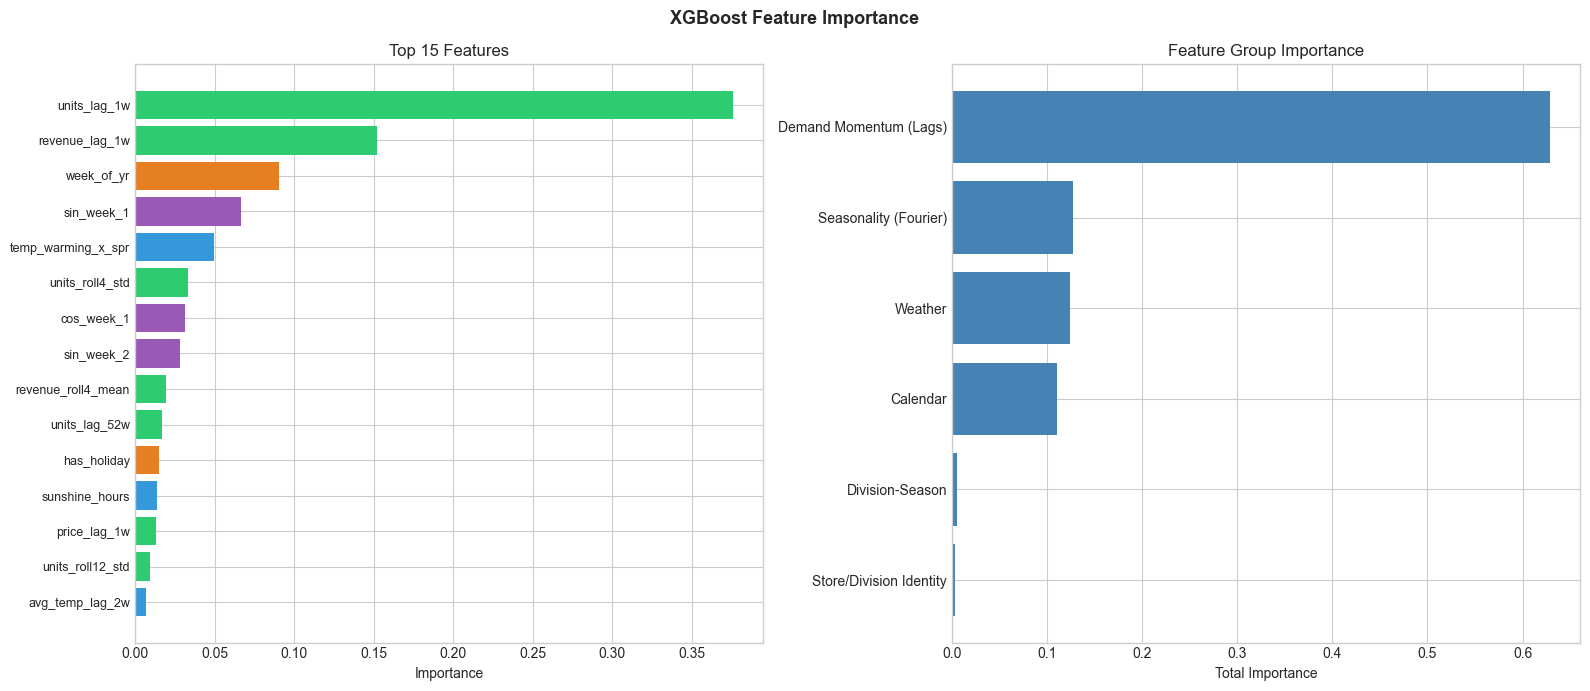


✅ Saved: feature_importance.png + feature_importance.csv


In [21]:
# Retrain final model on all available data
df_model_full = df_t1.dropna(subset=lag_cols_present).copy()
df_model_full['store_enc'] = le_store.transform(df_model_full['store_code'])
df_model_full['div_enc']   = le_div.transform(df_model_full['division_code'])

X_full = df_model_full[XGBOOST_FEATURES].fillna(0)
y_full = df_model_full['units']

final_model = XGBRegressor(
    n_estimators=300, max_depth=5, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8, min_child_weight=10,
    reg_alpha=0.5, reg_lambda=2.0, gamma=0.1,
    random_state=42, verbosity=0
)
final_model.fit(X_full, y_full, verbose=False)

importance = pd.DataFrame({
    'feature': XGBOOST_FEATURES,
    'importance': final_model.feature_importances_
}).sort_values('importance', ascending=False)

print('=' * 70)
print('FEATURE IMPORTANCE (XGBoost Global Model)')
print('=' * 70)
for _, row in importance.head(20).iterrows():
    bar = '█' * int(row['importance'] * 100)
    print(f'  {row["feature"]:<30} {row["importance"]:.4f}  {bar}')

# Categorize by group
group_importance = {}
for feat, imp in zip(importance['feature'], importance['importance']):
    if feat in LAG_FEATURES:
        grp = 'Demand Momentum (Lags)'
    elif feat in SEASONALITY_FEATURES:
        grp = 'Seasonality (Fourier)'
    elif feat in CALENDAR_FEATURES:
        grp = 'Calendar'
    elif feat in WEATHER_FEATURES:
        grp = 'Weather'
    elif feat in DIVISION_FEATURES:
        grp = 'Division-Season'
    elif feat in ['store_enc', 'div_enc']:
        grp = 'Store/Division Identity'
    else:
        grp = 'Other'
    group_importance[grp] = group_importance.get(grp, 0) + imp

print('\nImportance by feature group:')
for grp, imp in sorted(group_importance.items(), key=lambda x: -x[1]):
    bar = '█' * int(imp * 50)
    print(f'  {grp:<30} {imp:.3f}  {bar}')

# Plot
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

top15 = importance.head(15)
colors = []
for f in top15['feature']:
    if f in LAG_FEATURES: colors.append('#2ecc71')
    elif f in WEATHER_FEATURES: colors.append('#3498db')
    elif f in CALENDAR_FEATURES: colors.append('#e67e22')
    elif f in SEASONALITY_FEATURES: colors.append('#9b59b6')
    else: colors.append('#95a5a6')

axes[0].barh(range(len(top15)), top15['importance'].values, color=colors)
axes[0].set_yticks(range(len(top15)))
axes[0].set_yticklabels(top15['feature'].values, fontsize=9)
axes[0].invert_yaxis()
axes[0].set_xlabel('Importance')
axes[0].set_title('Top 15 Features')

grps = sorted(group_importance.items(), key=lambda x: -x[1])
axes[1].barh([g[0] for g in grps], [g[1] for g in grps], color='steelblue')
axes[1].invert_yaxis()
axes[1].set_xlabel('Total Importance')
axes[1].set_title('Feature Group Importance')

plt.suptitle('XGBoost Feature Importance', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES / 'feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

importance.to_csv(DATA_PROCESSED / 'feature_importance.csv', index=False)
print('\n✅ Saved: feature_importance.png + feature_importance.csv')

---
## Cell 8 — Prophet Comparison (High-Volume Groups Only)

Prophet is NOT the primary model. This is for benchmarking against XGBoost.
---

In [22]:
from prophet import Prophet

def run_prophet(group_df, regressors, eval_weeks_list, eval_horizon, confidence):
    # Prophet eval using in-season holdout weeks
    ts = (group_df.sort_values('week_ending')
                  .rename(columns={'week_ending': 'ds', 'units': 'y'}).copy())
    ts['y'] = ts['y'].clip(lower=0)
    avail_regs = [r for r in regressors if r in ts.columns and ts[r].notna().all()]

    ts_eval = ts[ts['ds'].isin(eval_weeks_list)].copy()
    if len(ts_eval) < MIN_HISTORY + eval_horizon:
        return None

    train = ts_eval.iloc[:-eval_horizon].copy()
    test  = ts_eval.iloc[-eval_horizon:].copy()

    if test['y'].sum() < 10:
        return None

    m = Prophet(yearly_seasonality=False, weekly_seasonality=False,
                daily_seasonality=False, interval_width=confidence,
                changepoint_prior_scale=0.1)
    for reg in avail_regs:
        m.add_regressor(reg, standardize=True)
    m.fit(train[['ds', 'y'] + avail_regs])

    future = m.make_future_dataframe(periods=eval_horizon, freq='W')
    future = future.merge(ts[['ds'] + avail_regs], on='ds', how='left')
    for reg in avail_regs:
        future[reg] = future[reg].fillna(future[reg].median())

    forecast = m.predict(future)
    preds = forecast.tail(eval_horizon)['yhat'].values.clip(min=0)
    actuals = test['y'].values

    abs_err = np.abs(actuals - preds)
    wmape = abs_err.sum() / max(actuals.sum(), 1)
    rmse  = np.sqrt(np.mean((actuals - preds)**2))
    mae   = np.mean(abs_err)
    bias  = np.mean(preds - actuals)
    return {'wMAPE': round(wmape, 4), 'RMSE': round(rmse, 2),
            'MAE': round(mae, 2), 'Bias': round(bias, 2),
            'Avg_Sales': round(actuals.mean(), 2)}

prophet_eligible = group_stats[group_stats['prophet_eligible'] == True]
prophet_results = []

print(f'Running Prophet on {len(prophet_eligible)} groups (in-season holdout)...')
print('-' * 75)

for _, row in prophet_eligible.iterrows():
    store, city, div = row['store_code'], row['city'], row['division_code']
    label = f'{store} ({city}) - {div}'
    grp = df[(df['store_code']==store) & (df['city']==city) &
             (df['division_code']==div)].copy()
    try:
        metrics = run_prophet(grp, PROPHET_REGRESSORS, eval_weeks, EVAL_HORIZON, CONFIDENCE_LEVEL)
        if metrics is None:
            print(f'  - {label:<40}  skipped (insufficient in-season data)')
            continue
        prophet_results.append({
            'store_code': store, 'city': city, 'division_code': div,
            **metrics, 'model': 'Prophet'
        })
        w = metrics['wMAPE']
        status = 'v' if w < 0.30 else '~' if w < 0.60 else '!'
        print(f'  {status} {label:<40}  wMAPE={w:.1%}  RMSE=${metrics["RMSE"]:,.0f}')
    except Exception as e:
        print(f'  x {label:<40}  ERROR: {e}')

prophet_accuracy = pd.DataFrame(prophet_results)
if len(prophet_accuracy) > 0:
    print(f'\nProphet median wMAPE (in-season): {prophet_accuracy["wMAPE"].median():.1%}')
else:
    print('\nNo Prophet models completed')


Running Prophet on 0 groups (in-season holdout)...
---------------------------------------------------------------------------

No Prophet models completed


---
## Cell 9 — Baseline Models + Full Comparison
---

In [23]:
baseline_results = []

for (store, city, div), grp in df[df['tier']=='xgboost'].groupby(GROUP_COLS):
    ts = grp.sort_values('week_ending')
    ts_eval = ts[ts['week_ending'].isin(eval_weeks)]
    if len(ts_eval) < MIN_HISTORY + EVAL_HORIZON:
        continue

    train = ts_eval.iloc[:-EVAL_HORIZON]
    test  = ts_eval.iloc[-EVAL_HORIZON:]
    actuals = test['units'].values

    if actuals.sum() < 10:
        continue

    naive_pred = train['units'].tail(min(4, len(train))).mean()
    naive_preds = np.full(len(actuals), naive_pred)
    naive_wmape = np.abs(actuals - naive_preds).sum() / actuals.sum()
    naive_rmse  = np.sqrt(np.mean((actuals - naive_preds)**2))

    ma_pred = train['units'].mean()
    ma_preds = np.full(len(actuals), ma_pred)
    ma_wmape = np.abs(actuals - ma_preds).sum() / actuals.sum()
    ma_rmse  = np.sqrt(np.mean((actuals - ma_preds)**2))

    baseline_results.append({
        'store_code': store, 'city': city, 'division_code': div,
        'Naive_wMAPE': round(naive_wmape, 4), 'Naive_RMSE': round(naive_rmse, 2),
        'MA_wMAPE': round(ma_wmape, 4), 'MA_RMSE': round(ma_rmse, 2),
    })

baseline_df = pd.DataFrame(baseline_results)

comparison = baseline_df.copy()
if len(xgb_accuracy) > 0:
    comparison = comparison.merge(
        xgb_accuracy[GROUP_COLS + ['wMAPE', 'RMSE']].rename(
            columns={'wMAPE': 'XGB_wMAPE', 'RMSE': 'XGB_RMSE'}),
        on=GROUP_COLS, how='left')
if len(prophet_accuracy) > 0:
    comparison = comparison.merge(
        prophet_accuracy[GROUP_COLS + ['wMAPE', 'RMSE']].rename(
            columns={'wMAPE': 'Prophet_wMAPE', 'RMSE': 'Prophet_RMSE'}),
        on=GROUP_COLS, how='left')

print('=' * 80)
print('MODEL COMPARISON - IN-SEASON HOLDOUT (all models, same period)')
print('=' * 80)

models_all = {}
if 'XGB_wMAPE' in comparison.columns:
    models_all['XGBoost']  = comparison['XGB_wMAPE'].dropna()
models_all['Naive']        = comparison['Naive_wMAPE'].dropna()
models_all['Moving Avg']   = comparison['MA_wMAPE'].dropna()
if 'Prophet_wMAPE' in comparison.columns:
    models_all['Prophet']  = comparison['Prophet_wMAPE'].dropna()

for name, vals in models_all.items():
    print(f'  {name:<20}: mean={vals.mean():.1%}  median={vals.median():.1%}  (n={len(vals)})')

# Head-to-head where both exist
has_xgb = comparison['XGB_wMAPE'].notna() if 'XGB_wMAPE' in comparison.columns else pd.Series(False, index=comparison.index)
has_prophet = comparison['Prophet_wMAPE'].notna() if 'Prophet_wMAPE' in comparison.columns else pd.Series(False, index=comparison.index)
comp_common = comparison[has_xgb & has_prophet].copy()

if len(comp_common) > 0:
    print(f'\n  Head-to-head ({len(comp_common)} groups with both XGBoost and Prophet):')
    xgb_wins     = (comp_common['XGB_wMAPE'] < comp_common['Prophet_wMAPE']).sum()
    prophet_wins = (comp_common['Prophet_wMAPE'] < comp_common['XGB_wMAPE']).sum()
    print(f'    XGBoost wins: {xgb_wins}  |  Prophet wins: {prophet_wins}')

    detail = comp_common[['store_code', 'division_code', 'XGB_wMAPE', 'Prophet_wMAPE',
                           'Naive_wMAPE']].copy()
    detail['winner'] = detail.apply(
        lambda r: 'XGBoost' if r['XGB_wMAPE'] < r['Prophet_wMAPE'] else 'Prophet', axis=1)
    detail = detail.sort_values('XGB_wMAPE')
    print(f'\n  Per-group detail:')
    print(detail.to_string(index=False))

# Best model per group
def pick_best(row):
    candidates = {'Naive': row['Naive_wMAPE'], 'MA': row['MA_wMAPE']}
    if pd.notna(row.get('XGB_wMAPE')): candidates['XGBoost'] = row['XGB_wMAPE']
    if pd.notna(row.get('Prophet_wMAPE')): candidates['Prophet'] = row['Prophet_wMAPE']
    best = min(candidates, key=candidates.get)
    return best, candidates[best]

comparison[['best_model', 'best_wMAPE']] = comparison.apply(
    lambda r: pd.Series(pick_best(r)), axis=1)

print(f'\n{"=" * 80}')
print('BEST MODEL PER GROUP')
print('=' * 80)
print(comparison['best_model'].value_counts().to_string())
print(f'\nMedian best-of wMAPE: {comparison["best_wMAPE"].median():.1%}')

under_30 = comparison[comparison['best_wMAPE'] < 0.30]
under_50 = comparison[comparison['best_wMAPE'] < 0.50]
print(f'Groups with wMAPE < 30%: {len(under_30)}')
print(f'Groups with wMAPE < 50%: {len(under_50)}')
if len(under_30) > 0:
    print(under_30[['store_code', 'division_code', 'best_model', 'best_wMAPE']].to_string(index=False))


MODEL COMPARISON - IN-SEASON HOLDOUT (all models, same period)
  XGBoost             : mean=60.7%  median=45.8%  (n=17)
  Naive               : mean=93.8%  median=90.9%  (n=17)
  Moving Avg          : mean=1689.8%  median=1606.4%  (n=17)

BEST MODEL PER GROUP
best_model
XGBoost    13
Naive       4

Median best-of wMAPE: 36.8%
Groups with wMAPE < 30%: 6
Groups with wMAPE < 50%: 13
store_code division_code best_model  best_wMAPE
      CP02            PC      Naive      0.0102
      CP04            PC    XGBoost      0.2687
      CP15            PC      Naive      0.2500
     CP202            PC    XGBoost      0.2698
      CP28            PC      Naive      0.1034
      CP37            PC    XGBoost      0.2446


---
## Cell 10 — Tier 3: Simple Baselines for Low-Volume Series
---

In [24]:
tier3_results = []
tier3_groups = group_stats[group_stats['tier'] == 'simple']

for _, row in tier3_groups.iterrows():
    store, city, div = row['store_code'], row['city'], row['division_code']
    grp = df[(df['store_code']==store) & (df['city']==city) &
             (df['division_code']==div)].sort_values('week_ending')
    if len(grp) < MIN_HISTORY + EVAL_HORIZON:
        continue
    train = grp.iloc[:-EVAL_HORIZON]
    test  = grp.iloc[-EVAL_HORIZON:]
    actuals = test['units'].values
    pred = train['units'].tail(4).mean()
    preds = np.full(len(actuals), pred)
    wmape = np.abs(actuals - preds).sum() / max(np.abs(actuals).sum(), 1e-6)
    tier3_results.append({
        'store_code': store, 'city': city, 'division_code': div,
        'wMAPE': round(wmape, 4), 'Avg_Sales': round(row['avg_sales'], 2),
        'CV': round(row['cv'], 2), 'model': 'Simple_Avg'
    })

tier3_df = pd.DataFrame(tier3_results)
if len(tier3_df) > 0:
    print('=' * 70)
    print('TIER 3 — LOW-VOLUME / INTERMITTENT (reported separately)')
    print('=' * 70)
    print(f'Groups: {len(tier3_df)}, Median wMAPE: {tier3_df["wMAPE"].median():.1%}')
    print(tier3_df.sort_values('wMAPE').to_string(index=False))
else:
    print('No Tier 3 groups')

TIER 3 — LOW-VOLUME / INTERMITTENT (reported separately)
Groups: 276, Median wMAPE: 75.0%
store_code                     city division_code        wMAPE  Avg_Sales   CV      model
      CP13            Victoriaville            TO 0.000000e+00       6.10 0.88 Simple_Avg
      CP08                Longueuil            TO 0.000000e+00       6.25 0.95 Simple_Avg
      CP40           Thetford Mines            PA 0.000000e+00       3.35 0.79 Simple_Avg
      CP40           Thetford Mines            LO 0.000000e+00      10.24 1.11 Simple_Avg
      CP12     St-Georges-de-Beauce            SP 0.000000e+00       2.00 0.70 Simple_Avg
      CP08                Longueuil            SP 0.000000e+00       1.87 0.62 Simple_Avg
      CP46  Sainte-Agathe-des-Monts            LO 0.000000e+00      17.43 1.18 Simple_Avg
      CP07              Liquidation            FI 0.000000e+00       1.12 0.31 Simple_Avg
      CP39                 Joliette            TO 0.000000e+00       4.16 0.78 Simple_Avg
      CP39

---
## Cell 11 — Production Forecast (Forward-Looking)

Recursive XGBoost forecast: predict t+1, feed back as lag input for t+2.
---

In [25]:
forecast_list = []
last_date = df['week_ending'].max()
forecast_dates = [last_date + pd.Timedelta(weeks=w) for w in range(1, FORECAST_HORIZON + 1)]

print(f'Forecast window: {forecast_dates[0].date()} → {forecast_dates[-1].date()}')

# ── Tier 1: XGBoost recursive ──
for (store, city, div), grp in df[df['tier']=='xgboost'].groupby(GROUP_COLS):
    grp = grp.sort_values('week_ending').copy()
    last_row = grp.iloc[-1]

    # Build full history buffer: last 52 rows of actual units
    hist_units = list(grp['units'].values[-52:])

    for step, fdate in enumerate(forecast_dates):
        row = {}
        for f in XGBOOST_FEATURES:
            # Skip features we'll populate manually below
            if f in ['units_lag_1w', 'units_lag_2w', 'units_lag_4w', 'units_lag_52w',
                      'units_roll4_mean', 'units_roll4_std',
                      'units_roll8_mean', 'units_roll8_std',
                      'units_roll12_mean', 'units_roll12_std',
                      'units_volatility']:
                continue
            elif f == 'store_enc':
                row[f] = le_store.transform([store])[0]
            elif f == 'div_enc':
                row[f] = le_div.transform([div])[0]
            elif f == 'week_of_yr':
                row[f] = fdate.isocalendar()[1]
            elif f == 'month':
                row[f] = fdate.month
            elif f == 'quarter':
                row[f] = (fdate.month - 1) // 3 + 1
            elif f in last_row.index:
                row[f] = last_row[f]
            else:
                row[f] = 0

        # ── Recursive lag features from history buffer ──
        n = len(hist_units)
        row['units_lag_1w']  = hist_units[-1] if n >= 1 else 0
        row['units_lag_2w']  = hist_units[-2] if n >= 2 else 0
        row['units_lag_4w']  = hist_units[-4] if n >= 4 else 0
        row['units_lag_52w'] = hist_units[-52] if n >= 52 else (last_row.get('units_lag_52w', 0) or 0)

        # Rolling windows — computed from history buffer
        for win in [4, 8, 12]:
            recent_w = hist_units[-win:] if n >= win else hist_units
            row[f'units_roll{win}_mean'] = np.mean(recent_w) if recent_w else 0
            row[f'units_roll{win}_std']  = np.std(recent_w) if len(recent_w) > 1 else 0

        # Demand volatility
        r4_mean = row.get('units_roll4_mean', 0)
        r4_std  = row.get('units_roll4_std', 0)
        row['units_volatility'] = (r4_std / r4_mean) if r4_mean > 0 else 0

        X_pred = pd.DataFrame([row])[XGBOOST_FEATURES].fillna(0)
        pred = max(0, final_model.predict(X_pred)[0])

        # Append prediction to history buffer for next recursive step
        hist_units.append(pred)

        forecast_list.append({
            'store_code': store, 'city': city, 'division_code': div,
            'Week': fdate, 'Forecast_Sales': round(pred, 2), 'model': 'XGBoost_Global'
        })

# ── Tier 3: Simple average ──
for (store, city, div), grp in df[df['tier']=='simple'].groupby(GROUP_COLS):
    avg = grp['units'].tail(4).mean()
    for fdate in forecast_dates:
        forecast_list.append({
            'store_code': store, 'city': city, 'division_code': div,
            'Week': fdate, 'Forecast_Sales': round(max(0, avg), 2), 'model': 'Simple_Avg'
        })

forecast_df = pd.DataFrame(forecast_list)
forecast_df['Week'] = pd.to_datetime(forecast_df['Week'])

print(f'Forecast output: {len(forecast_df):,} rows')

forecast_store = (
    forecast_df.groupby(['store_code', 'city', 'Week'])
    .agg(Forecast_Sales=('Forecast_Sales', 'sum')).reset_index()
)
print('\nStore-level forecast:')
print(forecast_store.head(20).to_string(index=False))

Forecast window: 2026-03-29 → 2026-04-19
Forecast output: 1,172 rows

Store-level forecast:
store_code          city       Week  Forecast_Sales
      CP02    Blainville 2026-03-29       75.730000
      CP02    Blainville 2026-04-05       74.599998
      CP02    Blainville 2026-04-12       80.060001
      CP02    Blainville 2026-04-19       79.880001
      CP04 Drummondville 2026-03-29      127.529999
      CP04 Drummondville 2026-04-05      130.919998
      CP04 Drummondville 2026-04-12      130.919998
      CP04 Drummondville 2026-04-19      218.559998
      CP05    Sherbrooke 2026-03-29      261.639999
      CP05    Sherbrooke 2026-04-05      268.110001
      CP05    Sherbrooke 2026-04-12      344.700012
      CP05    Sherbrooke 2026-04-19      682.049988
      CP06        Granby 2026-03-29      178.889999
      CP06        Granby 2026-04-05      246.360001
      CP06        Granby 2026-04-12      365.829987
      CP06        Granby 2026-04-19      403.820007
      CP07         Laval

---
## Cell 12 — Inventory Gap Analysis
---

In [26]:
inventaire = pd.read_excel(DATA_RAW / 'Exemple_Table_Inventaire.xlsx')
inventaire['store_code'] = inventaire['Location Code'].str.extract(r'(CP\d+)', expand=False)

inv_summary = (
    inventaire.groupby(['store_code', 'Division Code'])
    .agg(qty_available=('Quantity Available', 'sum'),
         inventory_value=('Inventory Value', 'sum'))
    .reset_index().rename(columns={'Division Code': 'division_code'})
)

forecast_demand = (
    forecast_df.groupby(['store_code', 'division_code'])['Forecast_Sales']
    .sum().reset_index().rename(columns={'Forecast_Sales': 'forecast_demand_total'})
)

gap = forecast_demand.merge(inv_summary, on=['store_code', 'division_code'], how='left')
gap['inventory_value'] = gap['inventory_value'].fillna(0)
gap['qty_available']   = gap['qty_available'].fillna(0)
gap['demand_vs_stock'] = gap['forecast_demand_total'] - gap['inventory_value']
gap['gap_flag'] = gap['demand_vs_stock'].apply(
    lambda x: '⚠️ Potential gap' if x > 0 else '✅ OK')

print(f'INVENTORY GAP ANALYSIS (next {FORECAST_HORIZON} weeks)')
print(gap.sort_values('demand_vs_stock', ascending=False).head(25).to_string(index=False))

INVENTORY GAP ANALYSIS (next 4 weeks)
store_code division_code  forecast_demand_total  qty_available  inventory_value  demand_vs_stock         gap_flag
      CP05            PC            1359.500000            0.0              0.0      1359.500000 ⚠️ Potential gap
      CP06            PC             885.899994            0.0              0.0       885.899994 ⚠️ Potential gap
      CP36            ME             631.000000            0.0              0.0       631.000000 ⚠️ Potential gap
      CP07            PC             566.430008            0.0              0.0       566.430008 ⚠️ Potential gap
      CP35            PC             499.300003            0.0              0.0       499.300003 ⚠️ Potential gap
      CP10            PC             448.340004            0.0              0.0       448.340004 ⚠️ Potential gap
      CP28            TO             448.000000            0.0              0.0       448.000000 ⚠️ Potential gap
      CP04            PC             424.929993   

---
## Cell 13 — Forecast Diagnostics
---

DIAGNOSTIC CHECKLIST

1. FORECAST BIAS: $32
   ⚠ Systematic over-prediction

2. MODEL VS BASELINES
   XGBoost median: 45.8%  |  Naive: 90.9%  |  MA: 1606.4%
   ✓ PASS — XGBoost outperforms both baselines

3. RESIDUAL NORMALITY: p=0.0001

4. DATA SUFFICIENCY: 73 weeks
   Tier 1: 17, Tier 3: 276, Skipped: 5

5. FEATURE IMPORTANCE
   Lags: 0.629  |  Weather: 0.124
   ✓ Demand momentum > Weather (consistent with analysis)


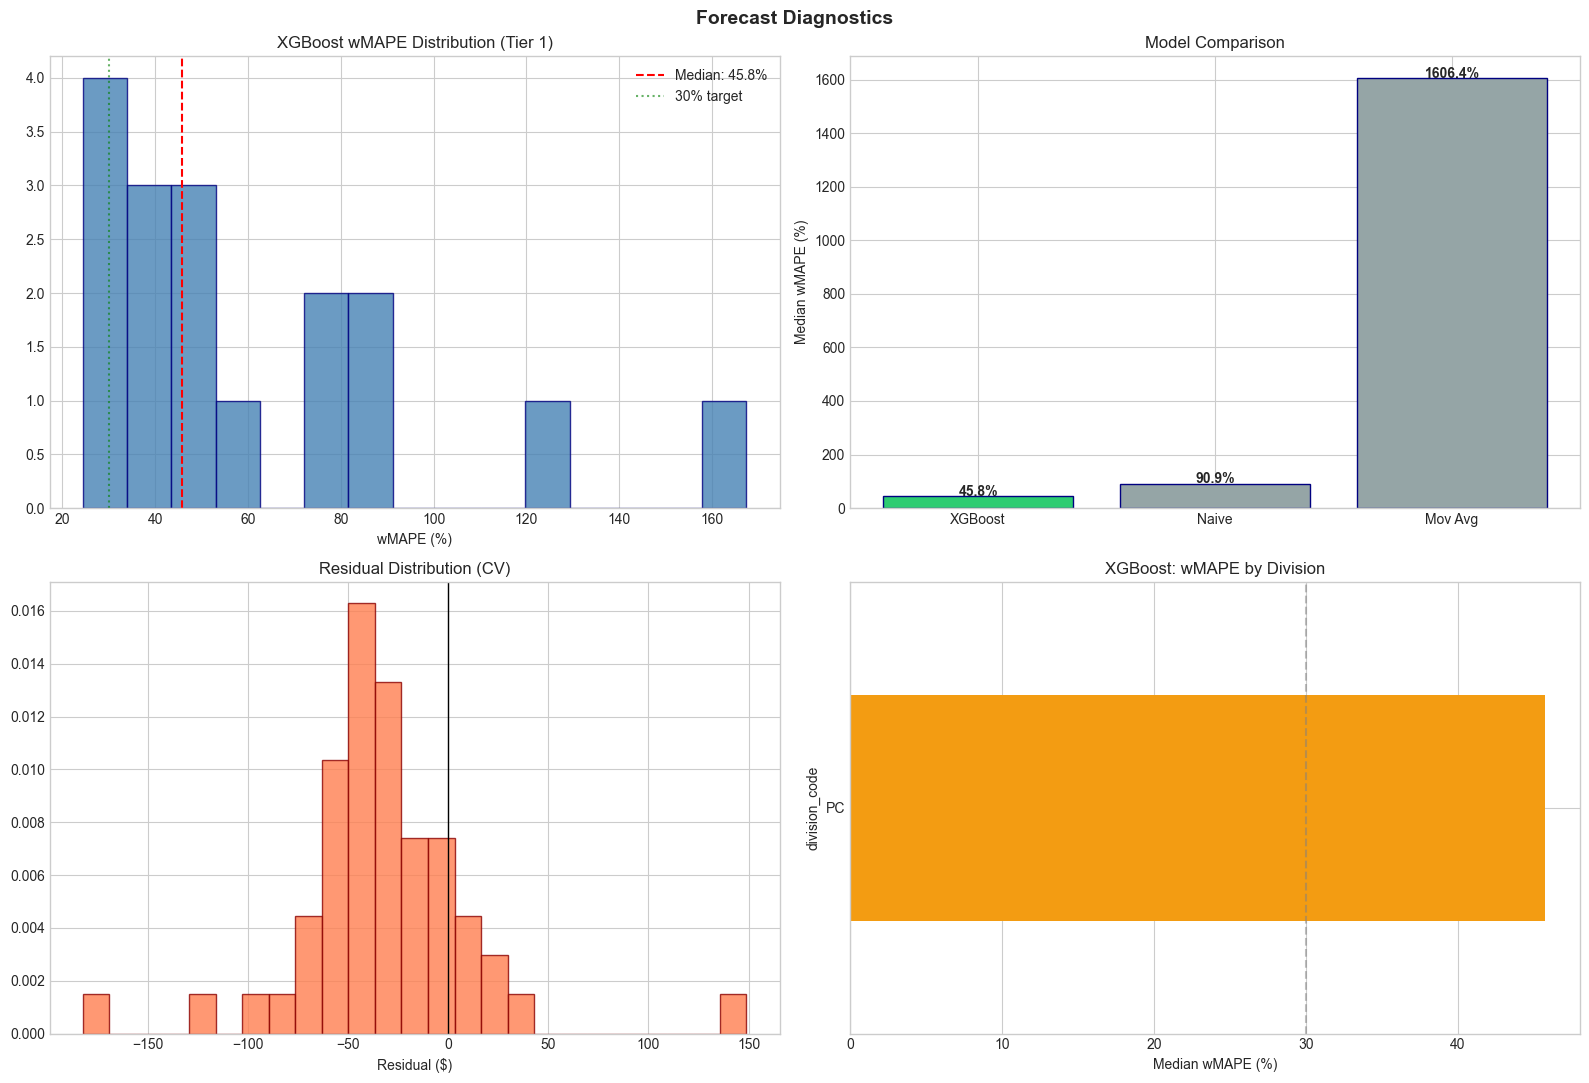


✅ Saved: forecast_diagnostics.png


In [27]:
print('=' * 80)
print('DIAGNOSTIC CHECKLIST')
print('=' * 80)

# 1. Bias
mean_bias = xgb_accuracy['Bias'].mean()
print(f'\n1. FORECAST BIAS: ${mean_bias:,.0f}')
if abs(mean_bias) < xgb_accuracy['MAE'].mean() * 0.15:
    print(f'   ✓ PASS')
else:
    print(f'   ⚠ Systematic {"over" if mean_bias > 0 else "under"}-prediction')

# 2. Model vs Baselines
print(f'\n2. MODEL VS BASELINES')
if 'XGB_wMAPE' in comparison.columns:
    xgb_med   = comparison['XGB_wMAPE'].median()
    naive_med = comparison['Naive_wMAPE'].median()
    ma_med    = comparison['MA_wMAPE'].median()
    print(f'   XGBoost median: {xgb_med:.1%}  |  Naive: {naive_med:.1%}  |  MA: {ma_med:.1%}')
    if xgb_med < naive_med and xgb_med < ma_med:
        print(f'   ✓ PASS — XGBoost outperforms both baselines')
    else:
        print(f'   ~ PARTIAL')

# 3. Residuals
residuals = cv_results['units'].values - cv_results['pred'].values
residuals = residuals[~np.isnan(residuals)]
if len(residuals) > 20:
    k2, p_norm = stats.normaltest(residuals)
    print(f'\n3. RESIDUAL NORMALITY: p={p_norm:.4f}')

# 4. Data Sufficiency
print(f'\n4. DATA SUFFICIENCY: {len(sorted_weeks)} weeks')
print(f'   Tier 1: {len(xgb_accuracy)}, Tier 3: {len(tier3_df)}, Skipped: {(group_stats["tier"]=="skip").sum()}')
if len(sorted_weeks) < 26:
    print(f'   ⚠ Short history — directional forecasts only')

# 5. Feature validation
print(f'\n5. FEATURE IMPORTANCE')
lag_imp = group_importance.get('Demand Momentum (Lags)', 0)
weather_imp = group_importance.get('Weather', 0)
print(f'   Lags: {lag_imp:.3f}  |  Weather: {weather_imp:.3f}')
if lag_imp > weather_imp:
    print(f'   ✓ Demand momentum > Weather (consistent with analysis)')

# ── Diagnostic plots ──
fig, axes = plt.subplots(2, 2, figsize=(16, 11))

if len(xgb_accuracy) > 0:
    axes[0,0].hist(xgb_accuracy['wMAPE']*100, bins=15, color='steelblue', edgecolor='navy', alpha=0.8)
    axes[0,0].axvline(xgb_accuracy['wMAPE'].median()*100, color='red', linestyle='--',
                      label=f'Median: {xgb_accuracy["wMAPE"].median():.1%}')
    axes[0,0].axvline(30, color='green', linestyle=':', alpha=0.6, label='30% target')
    axes[0,0].set_xlabel('wMAPE (%)')
    axes[0,0].set_title('XGBoost wMAPE Distribution (Tier 1)')
    axes[0,0].legend()

if 'XGB_wMAPE' in comparison.columns:
    model_medians = {'XGBoost': comparison['XGB_wMAPE'].median()*100,
                     'Naive': comparison['Naive_wMAPE'].median()*100,
                     'Mov Avg': comparison['MA_wMAPE'].median()*100}
    if 'Prophet_wMAPE' in comparison.columns and comparison['Prophet_wMAPE'].notna().any():
        model_medians['Prophet'] = comparison['Prophet_wMAPE'].median()*100
    colors = ['#2ecc71' if v == min(model_medians.values()) else '#95a5a6'
              for v in model_medians.values()]
    axes[0,1].bar(model_medians.keys(), model_medians.values(), color=colors, edgecolor='navy')
    axes[0,1].set_ylabel('Median wMAPE (%)')
    axes[0,1].set_title('Model Comparison')
    for i, (name, val) in enumerate(model_medians.items()):
        axes[0,1].text(i, val + 1, f'{val:.1f}%', ha='center', fontweight='bold')

if len(residuals) > 0:
    axes[1,0].hist(residuals, bins=25, color='coral', edgecolor='darkred', alpha=0.8, density=True)
    axes[1,0].axvline(0, color='black', linewidth=1)
    axes[1,0].set_title('Residual Distribution (CV)')
    axes[1,0].set_xlabel('Residual ($)')

if len(xgb_accuracy) > 0:
    div_wmape = xgb_accuracy.groupby('division_code')['wMAPE'].median().sort_values()
    colors = ['#2ecc71' if v < 0.30 else '#f39c12' if v < 0.60 else '#e74c3c' for v in div_wmape]
    (div_wmape*100).plot(kind='barh', ax=axes[1,1], color=colors)
    axes[1,1].axvline(30, color='grey', linestyle='--', alpha=0.5)
    axes[1,1].set_xlabel('Median wMAPE (%)')
    axes[1,1].set_title('XGBoost: wMAPE by Division')

plt.suptitle('Forecast Diagnostics', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES / 'forecast_diagnostics.png', dpi=150, bbox_inches='tight')
plt.show()
print('\n✅ Saved: forecast_diagnostics.png')

---
## Cell 14 — Save Outputs + Executive Summary
---

In [28]:
all_accuracy = pd.concat([xgb_accuracy, prophet_accuracy], ignore_index=True) if len(prophet_accuracy) > 0 else xgb_accuracy.copy()
all_accuracy.to_csv(DATA_PROCESSED / 'model_accuracy.csv', index=False)
comparison.to_csv(DATA_PROCESSED / 'baseline_comparison.csv', index=False)
forecast_df.to_csv(DATA_PROCESSED / 'forecast_output.csv', index=False)
forecast_store.to_csv(DATA_PROCESSED / 'forecast_output_by_store.csv', index=False)
gap.to_csv(DATA_PROCESSED / 'inventory_gap_analysis.csv', index=False)
if len(tier3_df) > 0:
    tier3_df.to_csv(DATA_PROCESSED / 'tier3_low_volume_accuracy.csv', index=False)

print(f'✅ model_accuracy.csv             ({len(all_accuracy)} groups)')
print(f'✅ baseline_comparison.csv        ({len(comparison)} groups)')
print(f'✅ forecast_output.csv            ({len(forecast_df):,} rows)')
print(f'✅ forecast_output_by_store.csv   ({len(forecast_store):,} rows)')
print(f'✅ inventory_gap_analysis.csv     ({len(gap)} rows)')

# ── Executive Summary ──
print()
print('=' * 80)
print('EXECUTIVE SUMMARY')
print('=' * 80)

store_totals = forecast_df.groupby(['store_code', 'city']).agg(
    Total_Forecast=('Forecast_Sales', 'sum')).reset_index()
store_acc = xgb_accuracy.groupby('store_code').agg(
    Median_wMAPE=('wMAPE', 'median'), N_Divisions=('division_code', 'count')).reset_index()
exec_summary = store_totals.merge(store_acc, on='store_code', how='left')
exec_summary['Status'] = exec_summary['Median_wMAPE'].apply(
    lambda x: '✓ Good' if x < 0.30 else '~ Review' if x < 0.60 else '⚠ Caution')

print(f'\nForecast horizon: {FORECAST_HORIZON} weeks | Primary model: XGBoost Global')
print()
print(exec_summary.to_string(index=False))

xgb_median  = xgb_accuracy['wMAPE'].median()
best_median = comparison['best_wMAPE'].median() if 'best_wMAPE' in comparison.columns else xgb_median

print(f'''
Key Findings:
  1. XGBoost Global median wMAPE: {xgb_median:.1%} (Tier 1 groups)
  2. Best-of-model median wMAPE : {best_median:.1%}
  3. {n_good} groups under 30% wMAPE, {n_ok} in 30–60% range
  4. Top predictors: demand momentum (lags) > seasonality > weather
  5. Data limitation: {len(sorted_weeks)} weeks — directional prototype

Architecture:
  - Tier 1 (XGBoost): {len(xgb_accuracy)} groups
  - Tier 2 (Prophet): {len(prophet_accuracy)} groups (comparison)
  - Tier 3 (Simple):  {len(tier3_df)} groups (low-volume)
  - Skipped: {(group_stats['tier']=='skip').sum()} groups

Recommendations:
  - Use Tier 1 forecasts for inventory planning (PC, GA, HT, ME, AP)
  - Tier 3: cross-check with store managers
  - Request full-year data for production accuracy (<20% target)
  - Power BI integration via forecast_output.csv
''')

✅ model_accuracy.csv             (17 groups)
✅ baseline_comparison.csv        (17 groups)
✅ forecast_output.csv            (1,172 rows)
✅ forecast_output_by_store.csv   (108 rows)
✅ inventory_gap_analysis.csv     (284 rows)

EXECUTIVE SUMMARY

Forecast horizon: 4 weeks | Primary model: XGBoost Global

store_code                     city  Total_Forecast  Median_wMAPE  N_Divisions    Status
      CP02               Blainville      310.270000        0.8249          1.0 ⚠ Caution
      CP04            Drummondville      607.929993        0.2687          1.0    ✓ Good
      CP05               Sherbrooke     1556.500000        0.4255          1.0  ~ Review
      CP06                   Granby     1194.899994        0.3406          1.0  ~ Review
      CP07                    Laval      854.430008        0.7772          1.0 ⚠ Caution
      CP07              Liquidation      157.000000        0.7772          1.0 ⚠ Caution
      CP08                Longueuil      382.590000        0.4501         